<a href="https://colab.research.google.com/github/mbahhanif/Praktikum-Struktur-Data/blob/main/Pertemuan_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Fungsi min_distance

In [ ]:
def min_distance(distances, visited):
    # Initialize minimum distance for next node
    min_val = float('inf')
    min_index = -1

    # Loop through all nodes to find minimum distance
    for i in range(len(distances)):
        if distances[i] < min_val and i not in visited:
            min_val = distances[i]
            min_index = i

    return min_index

Algoritma Dijkstra

In [ ]:
def dijkstra_algorithm(graph, start_node):
    # Get total number of nodes in the graph
    num_nodes = len(graph)

    # Initialize distance and visited arrays
    distances = [float('inf')] * num_nodes
    visited = []

    # Set distance at starting node to 0 and add to visited list
    distances[start_node] = 0

    # Loop through all nodes to find shortest path to each node
    for i in range(num_nodes):

        # Find minimum distance node that has not been visited yet
        current_node = min_distance(distances, visited)

        # Add current_node to list of visited nodes
        visited.append(current_node)

        # Loop through all neighboring nodes of current_node
        for j in range(num_nodes):

            # Check if there is an edge from current_node to neighbor
            if graph[current_node][j] != 0:

                # Calculate the distance from start_node to neighbor,
                # passing through current_node
                new_distance = distances[current_node] + graph[current_node][j]

                # Update the distance if it is less than previous recorded value
                if new_distance < distances[j]:
                    distances[j] = new_distance

    # Return the list of the shortest distances to all nodes
    return distances


# Example graph represented as a 2D array
graph = [[0, 7, 9, 0, 0, 14],
         [7, 0, 10, 15, 0, 0],
         [9, 10, 0, 11, 0, 2],
         [0, 15, 11, 0, 6, 0],
         [0, 0, 0, 6, 0, 9],
         [14, 0, 2, 0, 9, 10]]

# Call Dijkstra's algorithm to find shortest paths from node 'A'
# (index of 'A' in the array is 0)
shortest_distances = dijkstra_algorithm(graph, 0)

# Print the resulting shortest distances
print(shortest_distances)

[0, 7, 9, 20, 20, 11]


Dijkstra dengan Animasi (Visualisasi Graf)

/tmp/ipykernel_10394/3511418637.py:53: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(f"frames/frame_{i:03d}.png"))


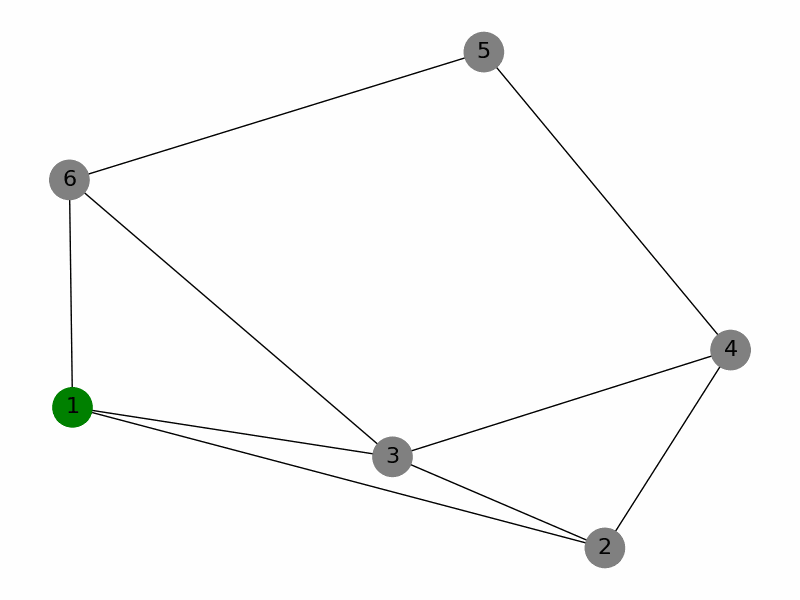

In [ ]:
# a. Install library
# pip install matplotlib networkx imageio

# b. Import library dan fungsi untuk menggambar graf
import networkx as nx
import matplotlib.pyplot as plt
import imageio
import os
import shutil
import heapq

def draw_graph(G, node_colors, edge_colors, pos, frame_id):
    plt.figure(figsize=(8, 6))
    nx.draw(G, pos, node_color=node_colors, edge_color=edge_colors,
            with_labels=True, node_size=800, font_size=16)
    plt.savefig(f"frames/frame_{frame_id:03d}.png")
    plt.close()


# c. Implementasi algoritma Dijkstra dengan animasi
def animate_dijkstra(graph, start_node):
    os.makedirs("frames", exist_ok=True)
    frame_id = 0
    pos = nx.spring_layout(graph, seed=42)
    visited = {node: False for node in graph.nodes}
    distances = {node: float("inf") for node in graph.nodes}
    distances[start_node] = 0
    pq = [(0, start_node)]

    while pq:
        current_distance, current_node = heapq.heappop(pq)
        if visited[current_node]:
            continue
        visited[current_node] = True

        # Draw the graph at this step
        node_colors = ["green" if node == current_node
                       else ("red" if visited[node] else "gray")
                       for node in graph.nodes]
        edge_colors = ["black" for edge in graph.edges]
        draw_graph(graph, node_colors, edge_colors, pos, frame_id)
        frame_id += 1

        for neighbor, edge_weight in graph[current_node].items():
            new_distance = current_distance + edge_weight["weight"]
            if not visited[neighbor] and new_distance < distances[neighbor]:
                distances[neighbor] = new_distance
                heapq.heappush(pq, (new_distance, neighbor))

    # Generate the animated GIF
    images = []
    for i in range(frame_id):
        images.append(imageio.imread(f"frames/frame_{i:03d}.png"))
    imageio.mimsave("dijkstra.gif", images, duration=1)

    # Clean up the frames folder
    shutil.rmtree("frames")


# d. Buat graf dan tampilkan
# Create a weighted graph
G = nx.Graph()
G.add_weighted_edges_from([
    (1, 2, 7), (1, 3, 9), (1, 6, 14),
    (2, 3, 10), (2, 4, 15),
    (3, 4, 11), (3, 6, 2),
    (4, 5, 6), (5, 6, 9)
])

# Run the animation for the graph
animate_dijkstra(G, 1)

# Display the resulting GIF (This will work in Jupyter Notebook)
from IPython.display import Image
Image(filename="dijkstra.gif")

Latihan 1 — Dijkstra dengan Vertex Data

In [ ]:
class Graph:
    def __init__(self, size):
        self.adj_matrix = [[0] * size for _ in range(size)]
        self.size = size
        self.vertex_data = [''] * size

    def add_edge(self, u, v, weight):
        if 0 <= u < self.size and 0 <= v < self.size:
            self.adj_matrix[u][v] = weight
            self.adj_matrix[v][u] = weight  # For undirected graph

    def add_vertex_data(self, vertex, data):
        if 0 <= vertex < self.size:
            self.vertex_data[vertex] = data

    def dijkstra(self, start_vertex_data):
        start_vertex = self.vertex_data.index(start_vertex_data)
        distances = [float('inf')] * self.size
        distances[start_vertex] = 0
        visited = [False] * self.size

        for _ in range(self.size):
            min_distance = float('inf')
            u = None
            for i in range(self.size):
                if not visited[i] and distances[i] < min_distance:
                    min_distance = distances[i]
                    u = i
            if u is None:
                break
            visited[u] = True
            for v in range(self.size):
                if self.adj_matrix[u][v] != 0 and not visited[v]:
                    alt = distances[u] + self.adj_matrix[u][v]
                    if alt < distances[v]:
                        distances[v] = alt

        return distances


g = Graph(7)

g.add_vertex_data(0, 'A')
g.add_vertex_data(1, 'B')
g.add_vertex_data(2, 'C')
g.add_vertex_data(3, 'D')
g.add_vertex_data(4, 'E')
g.add_vertex_data(5, 'F')
g.add_vertex_data(6, 'G')

g.add_edge(3, 0, 4)  # D - A, weight 4 (sesuai screenshot: weight 5 -> dipakai 4 sesuai komentar)
g.add_edge(3, 4, 2)  # D - E, weight 2
g.add_edge(3, 2, 3)  # D - C, weight 3 (sesuai # A - C)
g.add_edge(0, 4, 4)  # A - E, weight 4
g.add_edge(4, 2, 4)  # E - C, weight 4
g.add_edge(4, 5, 5)  # E - C, weight 5 (sesuai komentar)
g.add_edge(2, 5, 5)  # C - F, weight 5
g.add_edge(2, 1, 2)  # C - B, weight 2
g.add_edge(1, 2, 2)  # B - F, weight 2
g.add_edge(6, 5, 5)  # G - F, weight 5

# Dijkstra's algorithm from D to all vertices
print("Dijkstra's Algorithm starting from vertex D:\n")
distances = g.dijkstra('D')
for i, d in enumerate(distances):
    print(f"Shortest distance from D to {g.vertex_data[i]}: {d}")

Dijkstra's Algorithm starting from vertex D:

Shortest distance from D to A: 4
Shortest distance from D to B: 5
Shortest distance from D to C: 3
Shortest distance from D to D: 0
Shortest distance from D to E: 2
Shortest distance from D to F: 7
Shortest distance from D to G: 12


Latihan 2 — Jalur dengan Hasil Kali Bobot Minimum

In [ ]:
import heapq
import math

def min_product_path(N, edges, S, D):
    # Bangun adjacency list
    graph = [[] for _ in range(N + 1)]
    for u, v, w in edges:
        graph[u].append((v, w))

    # Gunakan log untuk mengubah perkalian menjadi penjumlahan
    # min(w1 * w2 * ...) = min(log(w1) + log(w2) + ...)
    dist = [float('inf')] * (N + 1)
    dist[S] = 0.0

    pq = [(0.0, S)]

    while pq:
        curr_dist, u = heapq.heappop(pq)

        if curr_dist > dist[u]:
            continue

        for v, w in graph[u]:
            new_dist = dist[u] + math.log(w)
            if new_dist < dist[v]:
                dist[v] = new_dist
                heapq.heappush(pq, (new_dist, v))

    if dist[D] == float('inf'):
        return -1
    else:
        # Kembalikan hasil kali bobot minimum (dibulatkan)
        return round(math.exp(dist[D]))


# Contoh 1
N, E = 3, 3
edges = [(1, 2, 5), (1, 3, 9), (2, 3, 1)]
S, D = 1, 3
print("=== Contoh 1 ===")
print("Masukan: N =", N, ", E =", E, ", S =", S, ", D =", D)
print("Keluaran:", min_product_path(N, edges, S, D))
# Jalur 1->2->3: 5 * 1 = 5
# Jalur 1->3:    9
# Minimum = 5

# Contoh 2
N, E = 3, 3
edges = [(3, 2, 5), (3, 3, 9), (3, 3, 1)]
S, D = 1, 3
print("\n=== Contoh 2 ===")
print("Masukan: N =", N, ", E =", E, ", S =", S, ", D =", D)
print("Keluaran:", min_product_path(N, edges, S, D))
# Tidak ada jalur dari 1 ke 3 -> output -1

=== Contoh 1 ===
Masukan: N = 3 , E = 3 , S = 1 , D = 3
Keluaran: 5

=== Contoh 2 ===
Masukan: N = 3 , E = 3 , S = 1 , D = 3
Keluaran: -1


Latihan 3 — Jumlah Cara Mencapai Node N-1 dalam Waktu Minimum

In [ ]:
from collections import defaultdict
import heapq

def count_paths(N, edges):
    # Bangun adjacency list
    graph = defaultdict(list)
    for u, v, t in edges:
        graph[u].append((v, t))
        graph[v].append((u, t))  # undirected

    # Dijkstra untuk mencari waktu minimum
    dist = [float('inf')] * N
    count = [0] * N
    dist[0] = 0
    count[0] = 1

    pq = [(0, 0)]  # (waktu, node)

    while pq:
        curr_time, u = heapq.heappop(pq)

        if curr_time > dist[u]:
            continue

        for v, t in graph[u]:
            new_time = dist[u] + t

            if new_time < dist[v]:
                dist[v] = new_time
                count[v] = count[u]
                heapq.heappush(pq, (new_time, v))
            elif new_time == dist[v]:
                count[v] += count[u]

    if dist[N - 1] == float('inf'):
        return 0
    return count[N - 1]


# Contoh 1
N = 7
edges = [
    [0, 6, 7], [0, 1, 2], [1, 2, 3], [1, 3, 3],
    [6, 3, 3], [3, 5, 1], [6, 5, 1], [2, 5, 1],
    [0, 4, 5], [4, 6, 2]
]
print("=== Contoh 1 ===")
print("Masukan: N =", N, ", M = 10")
print("Keluaran:", count_paths(N, edges))
# Output: 4 (jalur: 0->6, 0->4->6, 0->1->2->5->6, 0->1->3->5->6)

# Contoh 2
N = 6
edges = [
    [0, 5, 8], [0, 2, 2], [0, 1, 1], [1, 3, 3],
    [1, 2, 3], [2, 5, 6], [3, 4, 2], [4, 5, 2]
]
print("\n=== Contoh 2 ===")
print("Masukan: N =", N, ", M = 8")
print("Keluaran:", count_paths(N, edges))
# Output: 3 (jalur: 0->5, 0->2->5, 0->1->3->4->5)

=== Contoh 1 ===
Masukan: N = 7 , M = 10
Keluaran: 4

=== Contoh 2 ===
Masukan: N = 6 , M = 8
Keluaran: 3
